# S3 — MIC vs 1/SNR

Compute MIC (Maximal Information Coefficient) for each family across SNR levels,
with extra SNR values between 500 and ∞.

- x-axis: 1/SNR (left = clean, right = noisy)
- y-axis: MIC
- One line per family, colored by atom class

In [1]:
from __future__ import annotations
import math, os, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score

os.environ.setdefault('MPLCONFIGDIR', str(Path('.matplotlib').resolve()))
OUTPUT_DIR = Path('output/S3')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N = 500
N_REP = 3

FAMILY_TO_ATOM = {
    'F01': 'linear',   'F02': 'linear',
    'F03': 'convex',   'F06': 'convex',
    'F04': 'concave',  'F05': 'concave',
    'F13': 'inflected','F14': 'inflected',
    'F15': 'inflected','F16': 'inflected',
    'F17': 'u_shape',  'F18': 'u_shape',
    'F19': 'spike',    'F20': 'spike',
}

FAMILY_LABEL = {
    'F01': 'Linear +',      'F02': 'Linear \u2212',
    'F03': 'Power p>1 +',   'F04': 'Power p>1 \u2212',
    'F05': 'Power p<1 +',   'F06': 'Power p<1 \u2212',
    'F13': 'S-curve +',     'F14': 'S-curve \u2212',
    'F15': 'Threshold +',   'F16': 'Threshold \u2212',
    'F17': 'Inv-U',         'F18': 'U-shape',
    'F19': 'Spike \u2191',  'F20': 'Spike \u2193',
}

VARIANT_PARAMS = {
    'F01': [dict(slope=0.3), dict(slope=1.0), dict(slope=3.0)],
    'F02': [dict(slope=-0.3), dict(slope=-1.0), dict(slope=-3.0)],
    'F03': [dict(p=1.5), dict(p=2.5), dict(p=4.0)],
    'F04': [dict(p=1.5), dict(p=2.5), dict(p=4.0)],
    'F05': [dict(p=0.7), dict(p=0.5), dict(p=0.15)],
    'F06': [dict(p=0.7), dict(p=0.5), dict(p=0.15)],
    'F13': [dict(k=6,c=.5,L1=0,L2=1), dict(k=8,c=.5,L1=0,L2=1), dict(k=15,c=.5,L1=0,L2=1)],
    'F14': [dict(k=6,c=.5,L1=0,L2=1), dict(k=8,c=.5,L1=0,L2=1), dict(k=15,c=.5,L1=0,L2=1)],
    'F15': [dict(a=0,b=1,delta=.15,c=.5), dict(a=0,b=1,delta=.08,c=.5), dict(a=0,b=1,delta=.02,c=.5)],
    'F16': [dict(a=0,b=1,delta=.15,c=.5), dict(a=0,b=1,delta=.08,c=.5), dict(a=0,b=1,delta=.02,c=.5)],
    'F17': [dict(a=1,c=.5,d=0), dict(a=4,c=.5,d=0), dict(a=12,c=.5,d=0)],
    'F18': [dict(a=1,c=.5,d=0), dict(a=4,c=.5,d=0), dict(a=12,c=.5,d=0)],
    'F19': [dict(width=.08,c=.5), dict(width=.03,c=.5), dict(width=.01,c=.5)],
    'F20': [dict(width=.08,c=.5), dict(width=.03,c=.5), dict(width=.01,c=.5)],
}

_NEG = {'F04':'F03','F06':'F05','F14':'F13','F16':'F15','F20':'F19'}

def signal_fn(x, fid, p):
    if fid in _NEG:
        return -signal_fn(x, _NEG[fid], p)
    if fid in ('F01','F02'): return p['slope'] * x
    if fid in ('F03','F05'): return x ** p['p']
    if fid == 'F13':
        return p['L1'] + (p['L2']-p['L1']) / (1 + np.exp(-p['k']*(x-p['c'])))
    if fid == 'F15':
        t = np.clip((x-(p['c']-p['delta'])) / (2*p['delta']), 0, 1)
        return p['a'] + (p['b']-p['a']) * t
    if fid == 'F17': return -p['a']*(x-p['c'])**2 + p['d']
    if fid == 'F18': return  p['a']*(x-p['c'])**2 + p['d']
    if fid == 'F19': return np.exp(-np.abs(x-p['c'])/p['width'])
    raise ValueError(fid)

def sig_var(fid, p):
    x = np.linspace(0, 1, 20001)
    return max(np.var(signal_fn(x, fid, p), ddof=0), 1e-30)

def mic_e(x, y):
    """MIC with equipartition (MICe approximation)."""
    n = len(x)
    B = int(n ** 0.6)
    max_k = min(int(np.sqrt(B)), 12)
    best = 0.0
    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()
    for a in range(2, max_k + 1):
        xe = np.linspace(xmin, xmax, a + 1)[1:-1]
        xd = np.searchsorted(xe, x)
        for b in range(2, max_k + 1):
            if a * b > B:
                break
            ye = np.linspace(ymin, ymax, b + 1)[1:-1]
            yd = np.searchsorted(ye, y)
            mi = mutual_info_score(xd, yd)
            v = mi / np.log(min(a, b))
            if v > best:
                best = v
    return min(best, 1.0)

# Extended SNR grid: 0.1–500 (original range) + 500–500k (fill gap to \u221e)
SNR_GRID = sorted(set(
    np.geomspace(0.1, 500, 40).tolist() +
    np.geomspace(500, 500_000, 15).tolist()
))
FAMILIES = sorted(FAMILY_TO_ATOM)

print(f'Families: {len(FAMILIES)}')
print(f'Variants per family: 3')
print(f'Replicates: {N_REP}')
print(f'SNR levels: {len(SNR_GRID)} ({SNR_GRID[0]:.2f} \u2013 {SNR_GRID[-1]:.0f})')
total = len(FAMILIES) * 3 * len(SNR_GRID) * N_REP
print(f'Total MIC computations: {total:,}')

Families: 14
Variants per family: 3
Replicates: 3
SNR levels: 54 (0.10 – 500000)
Total MIC computations: 6,804


In [2]:
results = {}
t0 = time.time()

for fid in FAMILIES:
    variants = VARIANT_PARAMS[fid]
    mic_arr = np.zeros((len(variants), len(SNR_GRID), N_REP))
    for vi, p in enumerate(variants):
        sv = sig_var(fid, p)
        for si, snr in enumerate(SNR_GRID):
            sigma = math.sqrt(sv / snr)
            for ri in range(N_REP):
                seed = int(fid[1:]) * 1_000_000 + vi * 100_000 + si * 1000 + ri
                rng = np.random.default_rng(seed)
                x = rng.uniform(0, 1, N)
                y = signal_fn(x, fid, p) + rng.normal(0, sigma, N)
                mic_arr[vi, si, ri] = mic_e(x, y)
    results[fid] = mic_arr.mean(axis=(0, 2))
    print(f'  {fid} {FAMILY_LABEL[fid]:>16s}  ({time.time()-t0:.0f}s)')

print(f'\nDone in {time.time()-t0:.0f}s')

  F01         Linear +  (5s)
  F02         Linear −  (10s)
  F03      Power p>1 +  (15s)
  F04      Power p>1 −  (20s)
  F05      Power p<1 +  (25s)
  F06      Power p<1 −  (29s)
  F13        S-curve +  (34s)
  F14        S-curve −  (39s)
  F15      Threshold +  (44s)
  F16      Threshold −  (49s)
  F17            Inv-U  (53s)
  F18          U-shape  (58s)
  F19          Spike ↑  (63s)
  F20          Spike ↓  (68s)

Done in 68s


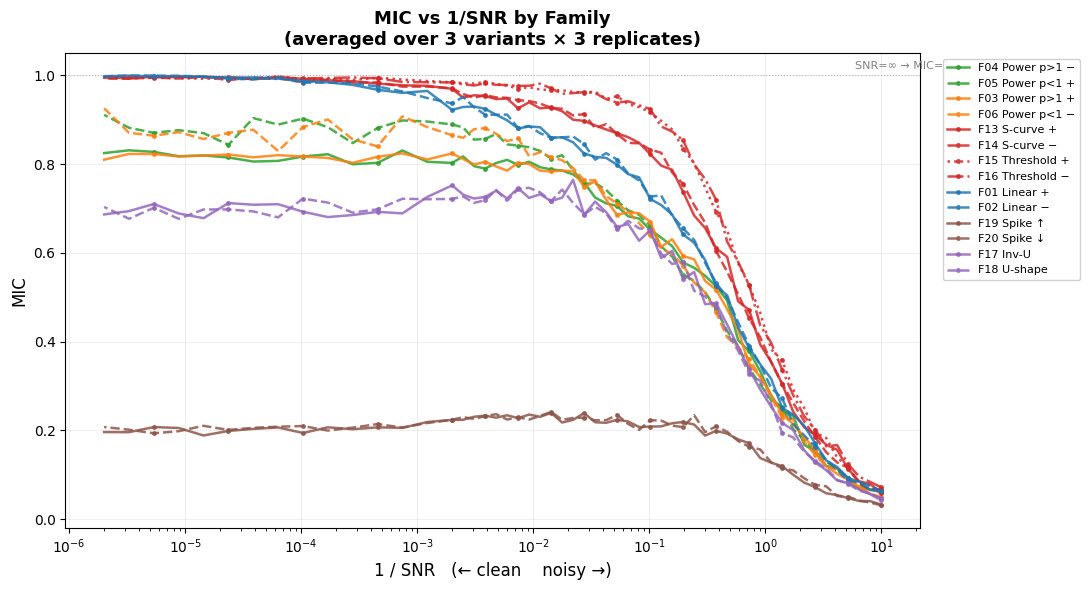

Saved output/S3/mic_vs_inv_snr.png


In [3]:
ATOM_COLORS = {
    'concave':   '#2ca02c',
    'convex':    '#ff7f0e',
    'inflected': '#d62728',
    'linear':    '#1f77b4',
    'spike':     '#8c564b',
    'u_shape':   '#9467bd',
}

atom_groups = {}
for fid in FAMILIES:
    atom_groups.setdefault(FAMILY_TO_ATOM[fid], []).append(fid)

inv_snr = 1.0 / np.array(SNR_GRID)
styles = ['-', '--', ':', '-.']

fig, ax = plt.subplots(figsize=(11, 6))

for atom in sorted(atom_groups):
    fids = atom_groups[atom]
    color = ATOM_COLORS[atom]
    for i, fid in enumerate(fids):
        ax.plot(inv_snr, results[fid], styles[i % 4],
                color=color, lw=1.8, alpha=0.85,
                label=f'{fid} {FAMILY_LABEL[fid]}',
                marker='o', ms=2.5, markevery=3)

ax.set_xscale('log')
ax.set_xlabel('1 / SNR   (\u2190 clean    noisy \u2192)', fontsize=12)
ax.set_ylabel('MIC', fontsize=12)
ax.set_title('MIC vs 1/SNR by Family\n(averaged over 3 variants \u00d7 3 replicates)',
             fontsize=13, fontweight='bold')
ax.set_ylim(-0.02, 1.05)
ax.axhline(1.0, color='gray', ls=':', lw=0.8, alpha=0.5)
ax.text(inv_snr[0] * 0.6, 1.015, 'SNR=\u221e \u2192 MIC=1', fontsize=8, color='gray')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, framealpha=0.9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mic_vs_inv_snr.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {OUTPUT_DIR / "mic_vs_inv_snr.png"}')